In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
schools_df = pd.read_csv("https://raw.githubusercontent.com/CunyLaguardiaDataAnalytics/datasets/master/2014-15_To_2016-17_School-_Level_NYC_Regents_Report_For_All_Variables.csv")

**General objective: to perform comparitive analysis of student test performance based on one or more comparison points**

**Step 1: Data exploration**

In [3]:
schools_df.shape

(212331, 15)

In [4]:
schools_df.columns

Index(['School DBN', 'School Name', 'School Level', 'Regents Exam', 'Year',
       'Total Tested', 'Mean Score', 'Number Scoring Below 65',
       'Percent Scoring Below 65', 'Number Scoring 65 or Above',
       'Percent Scoring 65 or Above', 'Number Scoring 80 or Above',
       'Percent Scoring 80 or Above', 'Number Scoring CR',
       'Percent Scoring CR'],
      dtype='object')

In [5]:
schools_df.head()

,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
0,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Common Core Algebra,2017,4,s,s,s,s,s,s,s,na,na
1,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2015,16,77.9,1,6.3,15,93.8,7,43.8,na,na
2,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2016,9,74,1,11.1,8,88.9,2,22.2,na,na
3,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2016,3,s,s,s,s,s,s,s,na,na
4,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2017,2,s,s,s,s,s,s,s,na,na


In [6]:
schools_df.tail()

,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
212326,84X717,Icahn Charter School,K-8,Living Environment,2016,8,s,s,s,s,s,s,s,na,na
212327,84X717,Icahn Charter School,K-8,Living Environment,2016,5,s,s,s,s,s,s,s,na,na
212328,84X717,Icahn Charter School,K-8,Living Environment,2017,6,s,s,s,s,s,s,s,na,na
212329,84X717,Icahn Charter School,K-8,Living Environment,2017,4,s,s,s,s,s,s,s,na,na
212330,84X717,Icahn Charter School,K-8,U.S. History and Government,2015,1,s,s,s,s,s,s,s,na,na


In [7]:
#min year
min_year = schools_df['Year'].min()
print(min_year)

2015


In [8]:
#max year
max_year = schools_df['Year'].max()
print(max_year)

2017


In [10]:
#serves two purposes: shows what school levels are part of this dataset and returns total tested by level. The results confirm my prior knowledge that Regents exams are mostly administered on a High School Level
schools_df.groupby(['School Level'])['Total Tested'].sum().sort_values(ascending=False)

,Total Tested
School Level,
High school,8580600
Secondary School,1090125
Junior High-Intermediate-Middle,448550
K-12 all grades,260225
K-8,101935
Elementary,115


In [11]:
#checking to see if a particular school of interest, High School of Economics and Finance (HSEF), is part of the dataset - it is
school_exists = schools_df['School Name'].isin(['High School of Economics and Finance']).any()
print(f"Is 'HSEF' on the list? {school_exists}")

Is 'HSEF' on the list? True


**Data exploration insight: the dataset contains Regents exam performance data for different levels of NYC schools accross several years, including metrics such as number tested, mean score, and percentage rate for different score levels. The dataset also contains a record of a particular school of interest, High School of Economics and Finance (HSEF)**

**Specific objective: to compare the metrics of HSEF to the combined metrics of High Schools citywide**

---



**Step 2: Data cleaning and exploration**

In [12]:
#creating a subset for High Schools citywide
hs_df = schools_df[schools_df['School Level'] == "High school"]
hs_df.shape

(151160, 15)

In [13]:
hs_df.head()

,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
18,01M292,Orchard Collegiate Academy,High school,Algebra2/Trigonometry,2015,5,s,s,s,s,s,s,s,na,na
19,01M292,Orchard Collegiate Academy,High school,Algebra2/Trigonometry,2016,5,s,s,s,s,s,s,s,na,na
20,01M292,Orchard Collegiate Academy,High school,Common Core Algebra,2015,12,52.3,11,91.7,1,8.3,0,0,0,0
21,01M292,Orchard Collegiate Academy,High school,Common Core Algebra,2016,50,63.9,25,50,25,50,3,6,15,30
22,01M292,Orchard Collegiate Academy,High school,Common Core Algebra,2017,53,67.5,15,28.3,38,71.7,6,11.3,29,54.7


In [14]:
#Dropping unnecessary columns - to make dataset simpler and more focused
newhs_df = hs_df.drop(columns= ['Mean Score', 'Total Tested','Number Scoring Below 65', 'Number Scoring 65 or Above', 'Number Scoring 80 or Above', 'Percent Scoring 80 or Above',	'Number Scoring CR',	'Percent Scoring CR'])
newhs_df.head()

,School DBN,School Name,School Level,Regents Exam,Year,Percent Scoring Below 65,Percent Scoring 65 or Above
18,01M292,Orchard Collegiate Academy,High school,Algebra2/Trigonometry,2015,s,s
19,01M292,Orchard Collegiate Academy,High school,Algebra2/Trigonometry,2016,s,s
20,01M292,Orchard Collegiate Academy,High school,Common Core Algebra,2015,91.7,8.3
21,01M292,Orchard Collegiate Academy,High school,Common Core Algebra,2016,50,50
22,01M292,Orchard Collegiate Academy,High school,Common Core Algebra,2017,28.3,71.7


In [16]:
#prior knowledge: a score of 65 or higher is generally considered a passing score for New York State Regents Examinations
#renaming 'Percent Scoring Above 65' and 'Percent Scoring below 65' to %Passed/%Failed
newhs_df = newhs_df.rename(columns={
    'Percent Scoring Below 65': '%Passed',
    'Percent Scoring 65 or Above': '%Failed'
})

newhs_df.columns

Index(['School DBN', 'School Name', 'School Level', 'Regents Exam', 'Year',
       '%Passed', '%Failed'],
      dtype='object')

In [19]:
#noticing occasional 's' values in %Passed/%Failed columns. Possible usage of 's' value in the dataset: signifies that the data is not reportable or missing due to low sample size.
#choosing to exclude rows with 's' value to avoid skewing results and to allow for numerical analysis
#deleting rows where column '%Passed' has the value 's' using Boolean indexing approach (keeps rows that are NOT 's')
citywide_hs_df = newhs_df[newhs_df['%Passed'] != 's']
citywide_hs_df.shape

(100930, 7)

In [20]:
#checking for additional 's' values in '%Failed' column. Result: no additional 's' vulues, i.e. no futher cleaning is needed
s_value = citywide_hs_df['%Failed'].isin(['s']).any()
print(f"Is 's' value on the list? {s_value}")

Is 's' value on the list? False


In [21]:
citywide_hs_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100930 entries, 20 to 212099
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   School DBN    100930 non-null  object
 1   School Name   100930 non-null  object
 2   School Level  100930 non-null  object
 3   Regents Exam  100930 non-null  object
 4   Year          100930 non-null  int64 
 5   %Passed       100930 non-null  object
 6   %Failed       100930 non-null  object
dtypes: int64(1), object(6)
memory usage: 6.2+ MB


In [22]:
#calculating median value for '%Passed'
citywide_hs_df['%Passed'].median()
#returns an error when applied to 'object' datatype

TypeError: Cannot convert ['91.7' '50' '28.3' ... '21.9' '16.7' '49.2'] to numeric

In [23]:
#converting values in %Passed/%Failed columns from 'object' to 'float' datatype in order to calculate statistics, such as median
citywide_hs_df['%Passed'] = citywide_hs_df['%Passed'].astype(float)
citywide_hs_df['%Failed'] = citywide_hs_df['%Failed'].astype(float)

/tmp/ipykernel_570/4194152000.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  citywide_hs_df['%Passed'] = citywide_hs_df['%Passed'].astype(float)
/tmp/ipykernel_570/4194152000.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  citywide_hs_df['%Failed'] = citywide_hs_df['%Failed'].astype(float)


In [24]:
#checking if datatype has been changed successfully - it has
citywide_hs_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 100930 entries, 20 to 212099
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   School DBN    100930 non-null  object 
 1   School Name   100930 non-null  object 
 2   School Level  100930 non-null  object 
 3   Regents Exam  100930 non-null  object 
 4   Year          100930 non-null  int64  
 5   %Passed       100930 non-null  float64
 6   %Failed       100930 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.2+ MB


In [25]:
#calculating median Passed and Failed rates. Median is preferred over Mean because of potential outliers
citywide_hs_df['%Passed'].median()

45.0

In [28]:
citywide_hs_df['%Failed'].median()
#%Passed + %Failed  = 100.0 which confirms reliability of the dataset

55.0

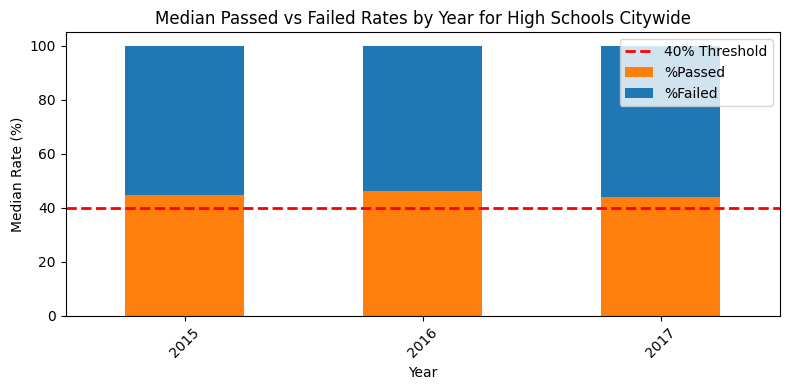

In [ ]:
#visualize median Passed vs Failed rates for High Schools citiwide by year
#group by year and calculate medians to see trends over time
yearly_citywide_stats = citywide_hs_df.groupby('Year')[['%Passed', '%Failed']].median()
#plot stacked bar chart
ax = yearly_citywide_stats.plot(kind='bar', stacked=True, figsize=(8, 4), color=['#ff7f0e', '#1f77b4'])
#customize plot
plt.title('Median Passed vs Failed Rates by Year for High Schools Citywide')
plt.ylabel('Median Rate (%)')
plt.xlabel('Year')
plt.axhline(y=40, color='r', linestyle='--', linewidth=2)
#add the 40% marking line (y=40)
plt.legend(['40% Threshold', '%Passed', '%Failed'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [29]:
#creating a new dataframe 'hsef_df' to subset for High School of Economics and Finance (HSEF)
hsef_df = citywide_hs_df[citywide_hs_df['School Name'] == "High School of Economics and Finance"]
hsef_df.shape

(347, 7)

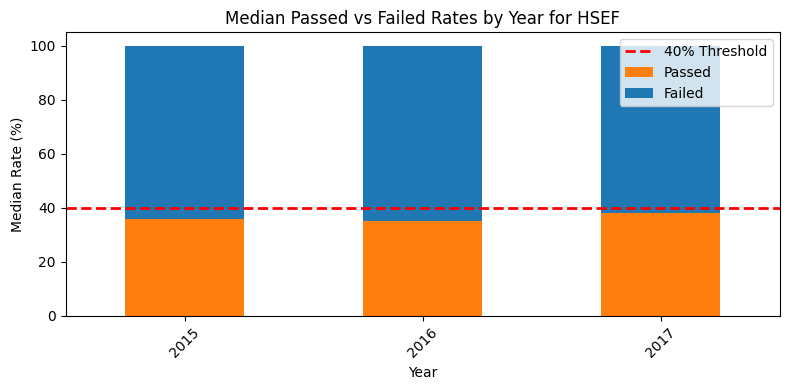

In [30]:
#visualize median Passed vs Failed rates for HSEF by year
#group by year and calculate medians
yearly_hsef_stats = hsef_df.groupby('Year')[['%Passed', '%Failed']].median()
#plot stacked bar chart
ax = yearly_hsef_stats.plot(kind='bar', stacked=True, figsize=(8, 4), color=['#ff7f0e', '#1f77b4'])
#customize plot
plt.title('Median Passed vs Failed Rates by Year for HSEF')
plt.ylabel('Median Rate (%)')
plt.xlabel('Year')
plt.axhline(y=40, color='r', linestyle='--', linewidth=2)
#add the 40% marking line (y=40)
plt.legend(['40% Threshold', 'Passed', 'Failed'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Insight 1: The median percentages of students passing Regents exams accross NYC High Schools and at High School of Economics and Finance (HSEF) remained relatively stable accross the analyzed years, suggesting that overall performance (whether for High Schools citywide or just for HSEF) did not experience dramatic fluctuations during this time period.**

**Adding a benchmark line set at 40% median rate to the bar chart was helpful in identifying the main difference between the trends, where High Schools citywide have shown to have a slightly better median passing rate than HSEF accross the analyzed years**

Text(0, 0.5, 'Regents Exam')

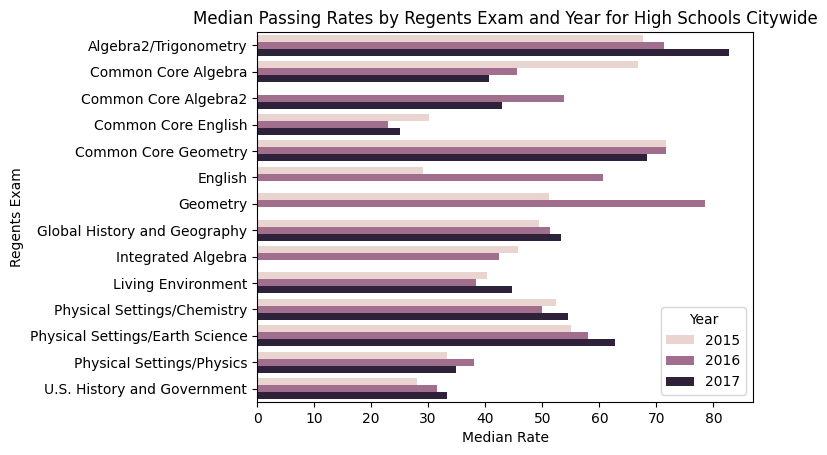

In [31]:
#median passing rate for High Schools citywide by Regents Exam and year
#first, get unique exams and sort them alphabetically
sorted_exams_citywide = sorted(citywide_hs_df['Regents Exam'].unique())

#use the 'order' parameter in the plot
sns.barplot(
    data=citywide_hs_df,
    x='%Passed',
    y='Regents Exam',
    hue='Year',
    order=sorted_exams_citywide,
    estimator = 'median',
    errorbar=None)

plt.title('Median Passing Rates by Regents Exam and Year for High Schools Citywide')
plt.xlabel('Median Rate')
plt.ylabel('Regents Exam')

Text(0, 0.5, 'Regents Exam')

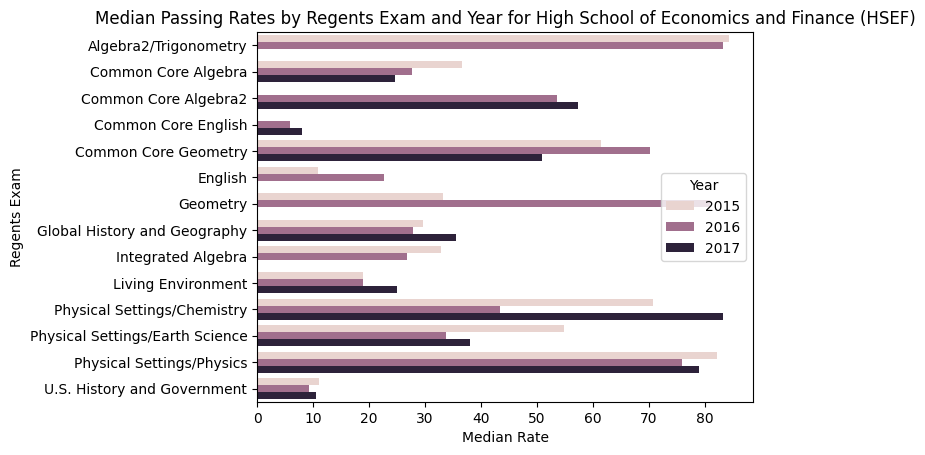

In [33]:
#median passing rate for HSEF by Regents Exam and year
#first, get unique exams and sort them alphabetically
sorted_exams_hsef = sorted(hsef_df['Regents Exam'].unique())

#use the 'order' parameter in the plot
sns.barplot(
    data=hsef_df,
    x='%Passed',
    y='Regents Exam',
    hue='Year',
    order=sorted_exams_hsef,
    estimator = 'median',
    errorbar=None)

plt.title('Median Passing Rates by Regents Exam and Year for High School of Economics and Finance (HSEF)')
plt.xlabel('Median Rate')
plt.ylabel('Regents Exam')

**Insight 2: exam-level analysis reveals variation in pass rates accross different Regents subjects, indicating that studnet performance differs by subject area, indicating that some subjects may present greater challenges for students. As for year-based analysis, it is not clear what factors may have contributed to the substantial difference in yearly pass rate for certain subjects. Possible contributors: variations in student body and in the amounts of unreported data**

/tmp/ipykernel_570/1638544349.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  citywide_hs_df['Source'] = 'City-Wide'
/tmp/ipykernel_570/1638544349.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hsef_df['Source'] = 'HSEF'


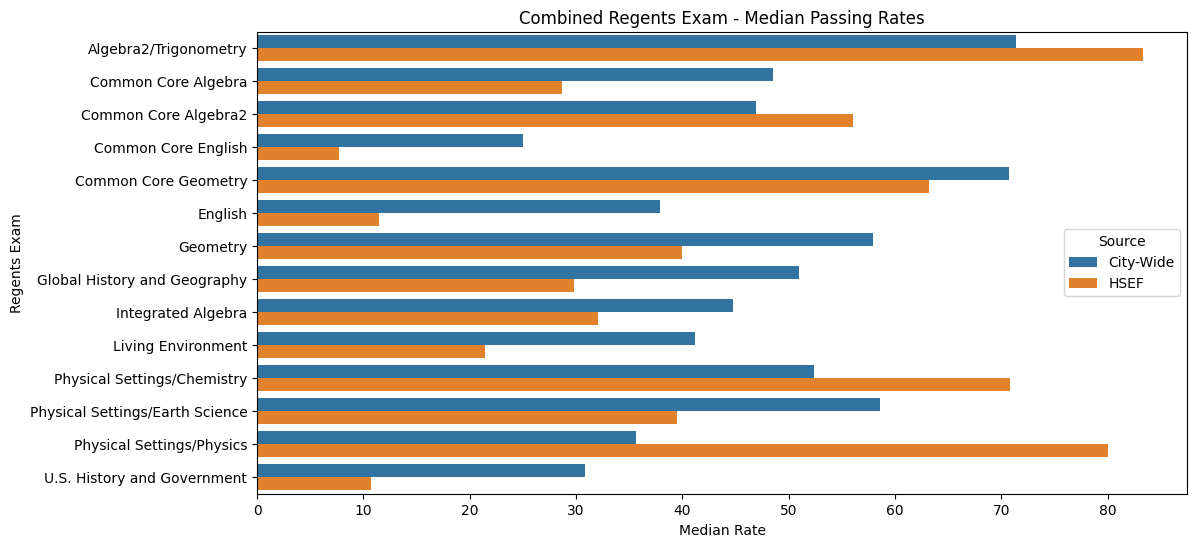

In [34]:
#first, adding identifiers to distinguish sources on the plot
citywide_hs_df['Source'] = 'City-Wide'
hsef_df['Source'] = 'HSEF'
combined_df = pd.concat([citywide_hs_df, hsef_df], ignore_index=True)
sorted_exams_combined = sorted(combined_df['Regents Exam'].unique())

plt.figure(figsize=(12, 6))
sns.barplot(
    data=combined_df,
    x='%Passed',
    y='Regents Exam',
    hue='Source',  # Use 'Source' to separate the two original dfs
    order=sorted_exams_combined,
    estimator='median',
    errorbar=None
)
plt.title('Combined Regents Exam - Median Passing Rates')
plt.xlabel('Median Rate')
plt.ylabel('Regents Exam')
#combined results for all three years: 2015, 2016, 2017
plt.show()

**Insight 3: When comparing HSEF to the citywide median performance, the HSEF's pass rates appear slightly lower. However, for the combination of analyzed years, the median perfomance of HSEF's students is generally higher in the following Regents subjects: Algebra2/Trigonometry, Common Core Algebra2, Physical Settings/Chemistry, and Physical Settings/Physics, suggesting strong academic focus and support in these subjects**